Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X shape: (2, 249, 5)
y shape: (2, 62)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 247, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 121, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,598 (662.49 KB)

 Trainable params: 169,598 (662.49 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.5839 - val_loss: 0.5444
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.5451 - val_loss: 0.5145
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.5163 - val_loss: 0.4819
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.4851 - val_loss: 0.4425
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.4447 - val_loss: 0.3965
Epoch 6/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.4042 - val_loss: 0.3475
Epoch 7/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.3512 - val_loss: 0.3030
Epoch 8/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 0.3025 - val_loss: 0.2673
Epoch 9/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 0.2606 - val_loss: 0.2372
Epoch 10/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.2522 - val_loss: 0.2127
Epoch 11/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.2296 - val_loss: 0.1937
Epoch 12/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 0.2164 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


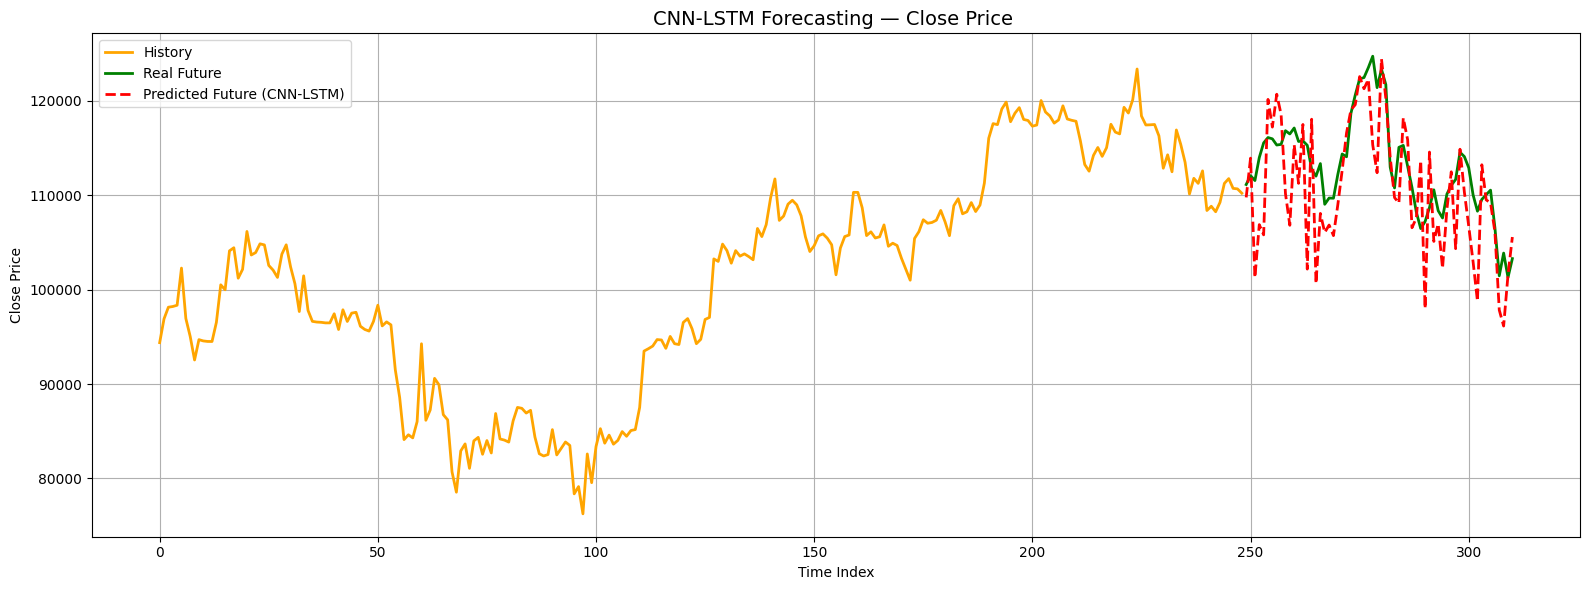

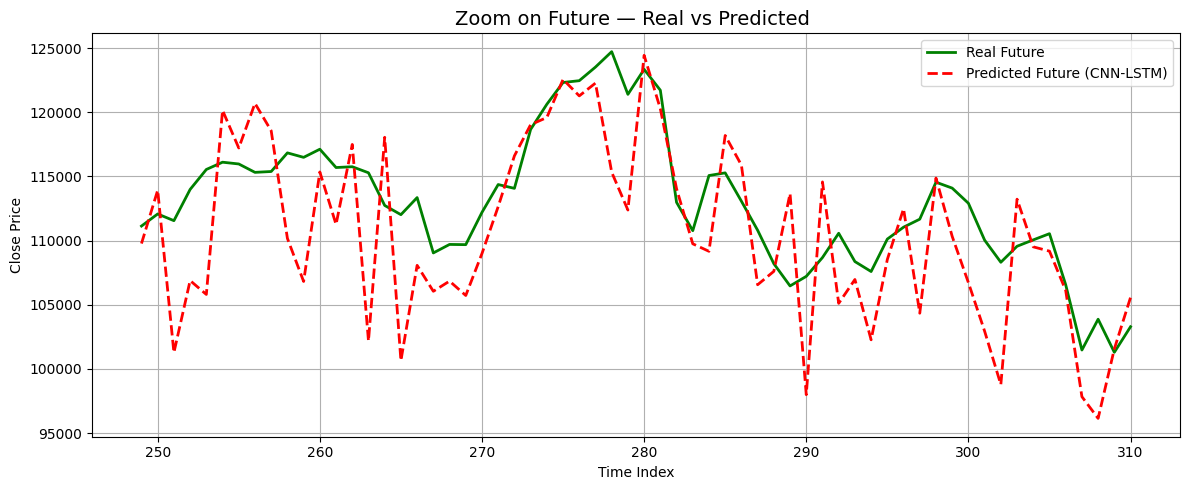

In [8]:
# -*- coding: utf-8 -*-
# =============================================================
#       CNN-LSTM Multivariate Time Series Forecast
#       Features: open, high, low, close, volume
#       History length:
#       Forecast length:
# =============================================================

!pip install -q tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# ------------------------------------------------
# 1) خواندن داده از Google Drive
# ------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/data/FINAL SELECTED DATA SET/Bitcoin.csv',
    sep=";",
    parse_dates=['merge_date'],
    dayfirst=True
)

# ------------------------------------------------
# 2) انتخاب ویژگی‌ها
# ------------------------------------------------
features = df[['open', 'high', 'low', 'close', 'volume']].astype(float)
values = features.values

# ------------------------------------------------
# 3) نرمال‌سازی
# ------------------------------------------------
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

# ------------------------------------------------
# 4) ساخت توالی‌های ورودی/خروجی
# ------------------------------------------------
HISTORY = 249
FORECAST = 62

X, y = [], []

for i in range(len(scaled) - HISTORY - FORECAST + 1):
    X.append(scaled[i:i+HISTORY])
    y.append(scaled[i+HISTORY:i+HISTORY+FORECAST, 3])   # پیش‌بینی ستون close

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)   # (samples, 150, 5)
print("y shape:", y.shape)   # (samples, 63)

# ------------------------------------------------
# 5) مدل CNN-LSTM
# ------------------------------------------------
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(HISTORY, 5)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(128, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(FORECAST)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# ------------------------------------------------
# 6) آموزش مدل
# ------------------------------------------------
history_fit = model.fit(
    X, y,
    epochs=40,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# ------------------------------------------------
# 7) پیش‌بینی روی آخرین تاریخچه
# ------------------------------------------------
last_seq = scaled[-HISTORY:]
last_seq = last_seq.reshape(1, HISTORY, 5)

pred_scaled = model.predict(last_seq)[0]

# برگرداندن scale برای close
dummy = np.zeros((FORECAST, 5))
dummy[:, 3] = pred_scaled
pred_close = scaler.inverse_transform(dummy)[:, 3]

# ------------------------------------------------
# 8) دادهٔ واقعی آینده (63 مقدار بعد از تاریخچه)
# ------------------------------------------------
actual_future = df['close'].values[HISTORY:HISTORY+FORECAST]
history_close = df['close'].values[:HISTORY]

# x-axis indices
history_idx = np.arange(HISTORY)
future_idx = np.arange(HISTORY, HISTORY + FORECAST)

# =================================================
# 9) رسم نمودار تمیز و پیوسته
# =================================================
plt.figure(figsize=(16,6))

# تاریخچه واقعی
plt.plot(history_idx, history_close, label='History', linewidth=2, color='orange')

# آینده واقعی
plt.plot(future_idx, actual_future, label='Real Future', linewidth=2, color='green')

# آینده پیش‌بینی
plt.plot(future_idx, pred_close, '--', label='Predicted Future (CNN-LSTM)', linewidth=2, color='red')

plt.title("CNN-LSTM Forecasting — Close Price ", fontsize=14)
plt.xlabel("Time Index")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =================================================
# 10) زوم روی آینده 63 روزه
# =================================================
plt.figure(figsize=(12,5))

plt.plot(future_idx, actual_future, label='Real Future ', linewidth=2, color='green')
plt.plot(future_idx, pred_close, '--', label='Predicted Future (CNN-LSTM)', linewidth=2, color='red')

plt.title("Zoom on Future — Real vs Predicted ", fontsize=14)
plt.xlabel("Time Index")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

